In [7]:
%load_ext autoreload
%autoreload 2

!export PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True

In [1]:
import os
os.chdir('/home/stud/ath/ath_ws/keypoint_matcher')

from config import config
from utils import logger
from utils import show_batch

import numpy as np
import torch
import torchvision
import torch.nn as nn
import torch.nn.functional as F

config.log_level = 'TRACE'

# torch.set_float32_matmul_precision('medium')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# torch.cuda.empty_cache()

# Check Data Module

In [2]:
from src import MatchesDataModule
dm = MatchesDataModule()

dm.setup(stage='fit')
dl = dm.train_dataloader()

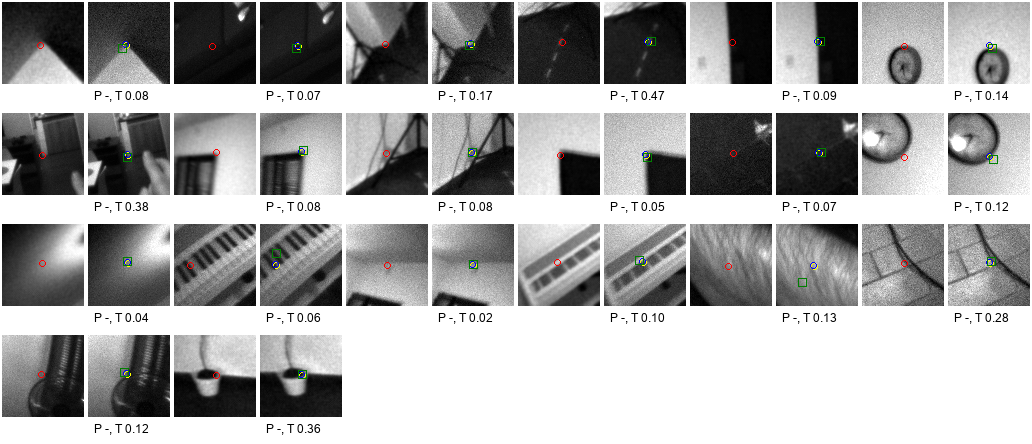

In [3]:
batch = next(iter(dl))
ref_patches, references, tar_patches, targets, confidences, cert, estimates = batch
# ref_patches, references, tar_patches, targets, confidences, cert = batch

# ref_patches = ref_patches.to(device)
# tar_patches = tar_patches.to(device)
# references = references.to(device)
# estimates = estimates.to(device)

# print(f'{ref_keypoints[:6]=}')
# print(f'{tar_keypoints[:6]=}')

count = 24 * 2

show_batch(
    ref_patches, tar_patches,
    references, 
    
    estimates,
    targets,

    confidences_true=confidences,
    estimates=estimates,
    
    limit_count=count, 

    n_columns=6,
    just_gt=False,
)

In [4]:
# import matplotlib.pyplot as plt
# import seaborn as sns
# import numpy as np

# def plot_confidence_distribution(dataloader, N=None):
#     all_confidences = []
    
#     for i, batch in enumerate(dataloader):
#         if N is not None and i >= N:
#             break
#         _, _, _, _, confidences, _, _ = batch
#         all_confidences.extend(confidences.cpu().numpy())
    
#     all_confidences = np.array(all_confidences)
    
#     # Adjust for skewed distribution by equalizing bins
#     min_conf, max_conf = all_confidences.min(), all_confidences.max()
#     bins = np.linspace(min_conf, max_conf, 30)
    
#     plt.figure(figsize=(8, 5))
#     sns.histplot(all_confidences, bins=bins, kde=True)
#     plt.xlabel("Confidence Scores")
#     plt.ylabel("Frequency")
#     plt.title("Distribution of Confidence Scores Across All Patches")
#     plt.grid()
#     plt.show()


# dl = dm.train_dataloader()
# plot_confidence_distribution(dl)

# Light

In [14]:
# torch.cuda.empty_cache()

from src import Light
light = Light()

from utils import count_params
num = count_params(light.model)
print(f"{num:,}")

9,804,207


In [15]:
# torch.cuda.empty_cache()

target_coords, target_confidences = light(
    ref_patches, 
    tar_patches, 
    references,
    estimates,
)

print(f'{target_coords.shape=}')
print(f'{target_confidences.shape=}')

target_coords.shape=torch.Size([20, 2])
target_confidences.shape=torch.Size([20, 1])
